<a href="https://colab.research.google.com/github/EsserMishelle/hotel-forecast/blob/main/eda-and-cancellation-prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hotel Booking Analysis
This project explores hotel booking demand patterns using a real-world dataset containing reservation information for both city hotels and resort hotels. The goal of the analysis is to understand booking behavior, cancellation patterns, seasonal trends, and factors that influence hotel demand.

--------------------

## Problem Statement

The hospitality industry operates in a highly competitive environment where understanding customer booking behavior is essential for improving operational efficiency and revenue management. Hotels must analyze patterns in reservations, cancellations, pricing, and customer preferences to make informed business decisions.

This project uses exploratory data analysis (EDA) on a hotel booking dataset to identify trends in demand, customer behavior, and booking characteristics. The analysis aims to uncover insights that can support strategic decision-making related to pricing strategies, marketing efforts, and service improvements.

------------------

### Data Description

The dataset contains hotel booking information including customer, reservation, and stay characteristics. Each row represents a single hotel reservation.

Key variables used in the analysis include:

| Column | Description |
|------|-------------|
| hotel | Type of hotel (City Hotel or Resort Hotel) |
| lead_time | Number of days between booking and arrival |
| arrival_date_year | Year of arrival |
| arrival_date_month | Month of arrival |
| stays_in_weekend_nights | Number of weekend nights booked |
| stays_in_week_nights | Number of weekday nights booked |
| adults, children, babies | Number of guests in the reservation |
| market_segment | Market segment category |
| is_canceled | Indicates whether the booking was canceled |
| adr | Average Daily Rate (room price per night) |
| customer_type | Type of customer making the reservation |

--------------------------------

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import time
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


### Load the Clean Dataset from Google Drive Obtained From Kaggel

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Define folder path within the drive
folder_path = '/content/drive/MyDrive/hotel-forecast'
os.makedirs(folder_path, exist_ok=True)

# Define the assets folder path
assets_folder_path = '/content/drive/MyDrive/hotel-forecast/assets'
os.makedirs(assets_folder_path, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df= pd.read_csv(os.path.join(folder_path, 'hotels.csv'))

-----------------------------------------

### Exploratory Data Analysis
This section focuses on preparing the dataset for analysis by handling missing values, removing duplicates, and ensuring the data is clean and consistent for further exploration.

Dataset Preview

In [ ]:
# Display all columns without skipping
pd.set_option('display.max_columns', None)

display(df.head(5))
display(df.tail(5))

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,0.0,0,HB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


Data Types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

Statiscal Description of Numeric Features

In [ ]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


Duplicates

In [ ]:
len(df[df.duplicated()])

31994

Null Values

In [ ]:
# Null value counts
null_counts=df.isnull().sum()

# Null value percentage
null_percentage = round(null_counts/len(df) * 100, 3)

null_summary = pd.DataFrame({'Null count': null_counts, 'Null percentage': null_percentage})
null_summary = null_summary[null_summary['Null count'] > 0]
print(null_summary)

          Null count  Null percentage
children           4            0.003
country          488            0.409
agent          16340           13.686
company       112593           94.307


The hotel DataFrame contains 119,390 entries and 32 columns. It has null values in the following fields: children (4), country (452), agent (12,193), and company (82,137). Additionally, there are 31,994 duplicate entries.

Unique Values

In [ ]:
df.nunique()

,0
hotel,2
is_canceled,2
lead_time,479
arrival_date_year,3
arrival_date_month,12
arrival_date_week_number,53
arrival_date_day_of_month,31
stays_in_weekend_nights,17
stays_in_week_nights,35
adults,14


Unique Values in Selected List of Variables

In [ ]:
unique_list_cols = ['hotel', 'is_canceled','arrival_date_year', 'adults', 'children',
                    'babies', 'market_segment','distribution_channel',
                    'is_repeated_guest', 'reserved_room_type', 'assigned_room_type',
                    'deposit_type', 'customer_type', 'reservation_status']


In [ ]:
for col in unique_list_cols:
    print(f'{col}: {df[col].unique()}')
    print('')

hotel: ['Resort Hotel' 'City Hotel']

is_canceled: [0 1]

arrival_date_year: [2015 2016 2017]

adults: [ 2  1  3  4 40 26 50 27 55  0 20  6  5 10]

children: [ 0.  1.  2. 10.  3. nan]

babies: [ 0  1  2 10  9]

market_segment: ['Direct' 'Corporate' 'Online TA' 'Offline TA/TO' 'Complementary' 'Groups'
 'Undefined' 'Aviation']

distribution_channel: ['Direct' 'Corporate' 'TA/TO' 'Undefined' 'GDS']

is_repeated_guest: [0 1]

reserved_room_type: ['C' 'A' 'D' 'E' 'G' 'F' 'H' 'L' 'P' 'B']

assigned_room_type: ['C' 'A' 'D' 'E' 'G' 'F' 'I' 'B' 'H' 'P' 'L' 'K']

deposit_type: ['No Deposit' 'Refundable' 'Non Refund']

customer_type: ['Transient' 'Contract' 'Transient-Party' 'Group']

reservation_status: ['Check-Out' 'Canceled' 'No-Show']



---------------------------

### Data Cleaning and transformation

Remove Duplicated Transactions

In [ ]:
# Make a copy of the raw, original DataFrame and not touch it
df_raw = df.copy()
df.shape
df_raw.shape

# Revert it back if there's a mistake
# df = df_raw.copy()
# df.shape

(119390, 32)

In [ ]:
# Modify df for analysis by dropping duplicates
df = df.drop_duplicates()

In [ ]:
# Confirm the remaining number of transaction is
# original number (119,390) - duplicated number (31,994) = 87396
df.shape

(87396, 32)

The `children` and `agent` columns contain float values, so missing values were replaced with 0.0 to maintain the numeric float structure of the variables.
The `country` column is categorical, therefore missing values were replaced with 'Unknown'. The `company` column contained over 90% missing values and was removed from the dataset as it provides limited analytical value.


In [ ]:
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0.0)
df['children'] = df['children'].fillna(0.0)
df = df.drop(columns = ['company'])

In [ ]:
# Confirm no nulls
df.isnull().sum().sum()

np.int64(0)

Transform Datatypes

In [ ]:
# Children and Agent should be interger type.
df['children'] = df['children'].astype('int64')
df['agent'] = df['agent'].astype('int64')
# Reservation_status_date should be datetime type
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

Remove rows with negative adr values

In [ ]:
# Negative average daily rate (adr) value.
df[df['adr'] < 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,0,0,BB,GBR,Groups,Direct,1,0,2,A,H,2,No Deposit,273,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


In [ ]:
# Since it is only 1 row, this transaction is removed.
df = df[df['adr'] >= 0]
df.shape

(87395, 31)

Remove rows with unrealistic occupancy.

Most hotel rooms accommondate 2-4 people, with extreme limit of 6 people per room. Observations with more than 6 total guests are removed because they likely reflect data entry or aggregation issues rather than realistic single-room bookings.
Zero occupany rows are also removed.



In [ ]:
df['total_guests'] = df['adults'] + df['children'] + df['babies']
display(df[df['total_guests'] > 6])
df = df[df['total_guests'] <= 6]
print(df.shape)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests
328,Resort Hotel,1,55,2015,July,29,12,4,10,2,10,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,D,D,2,No Deposit,8,0,Contract,133.16,0,1,No-Show,2015-07-12,12
1539,Resort Hotel,1,304,2015,September,36,3,0,3,40,0,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,0,0,Group,0.00,0,0,Canceled,2015-01-02,40
1587,Resort Hotel,1,333,2015,September,36,5,2,5,26,0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,96,0,Group,0.00,0,0,Canceled,2015-01-02,26
1643,Resort Hotel,1,336,2015,September,37,7,1,2,50,0,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,0,0,Group,0.00,0,0,Canceled,2015-01-18,50
1752,Resort Hotel,1,340,2015,September,37,12,2,5,26,0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,96,0,Group,0.00,0,0,Canceled,2015-01-02,26
1884,Resort Hotel,1,347,2015,September,38,19,2,5,26,0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,96,0,Group,0.00,0,0,Canceled,2015-01-02,26
1917,Resort Hotel,1,349,2015,September,39,21,1,3,27,0,0,HB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,0,0,Group,0.00,0,0,Canceled,2015-01-02,27
1962,Resort Hotel,1,352,2015,September,39,24,1,3,27,0,0,HB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,0,0,Group,0.00,0,0,Canceled,2015-01-02,27
2003,Resort Hotel,1,354,2015,September,39,26,2,5,26,0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,96,0,Group,0.00,0,0,Canceled,2015-01-02,26
2164,Resort Hotel,1,361,2015,October,40,3,2,5,26,0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,96,0,Group,0.00,0,0,Canceled,2015-01-02,26


(87379, 32)


Remove zero-guest bookings

In [ ]:
zero_guest = df[df['total_guests'] <= 0]
display(zero_guest)
print(f'Zero guest is {len(zero_guest)/len(df) * 100:.2f}% of total bookings')

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,1,No Deposit,0,0,Transient-Party,0.00,0,0,Check-Out,2015-10-06,0
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,0,No Deposit,0,0,Transient,0.00,0,0,Check-Out,2015-10-12,0
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,0,0,SC,ESP,Groups,TA/TO,0,0,0,A,C,0,No Deposit,38,0,Transient-Party,0.00,0,0,Check-Out,2015-11-23,0
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,0,0,SC,PRT,Groups,TA/TO,0,0,0,A,A,1,No Deposit,308,122,Transient-Party,0.00,0,0,Check-Out,2016-01-04,0
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,0,0,SC,PRT,Groups,TA/TO,0,0,0,A,C,1,No Deposit,308,122,Transient-Party,0.00,0,0,Check-Out,2016-01-05,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115029,City Hotel,0,107,2017,June,26,27,0,3,0,0,0,BB,CHE,Online TA,TA/TO,0,0,0,A,A,1,No Deposit,7,0,Transient,100.80,0,0,Check-Out,2017-06-30,0
115091,City Hotel,0,1,2017,June,26,30,0,1,0,0,0,SC,PRT,Complementary,Direct,0,0,0,E,K,0,No Deposit,0,0,Transient,0.00,1,1,Check-Out,2017-07-01,0
116251,City Hotel,0,44,2017,July,28,15,1,1,0,0,0,SC,SWE,Online TA,TA/TO,0,0,0,A,K,2,No Deposit,425,0,Transient,73.80,0,0,Check-Out,2017-07-17,0
116534,City Hotel,0,2,2017,July,28,15,2,5,0,0,0,SC,RUS,Online TA,TA/TO,0,0,0,A,K,1,No Deposit,9,0,Transient-Party,22.86,0,1,Check-Out,2017-07-22,0


Zero guest is 0.19% of total bookings


In [ ]:
df = df[df['total_guests'] > 0]
print(df.shape)

(87213, 32)


In [ ]:
zero_adr = df[df['adr'] ==0]
display(zero_adr)
print(f'Zero Adverage Daily Rate is {len(zero_adr)/len(df) * 100:.2f}% of total bookings')

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2
125,Resort Hotel,0,32,2015,July,27,4,0,1,4,0,0,FB,PRT,Complementary,Direct,0,0,0,H,H,2,No Deposit,0,0,Transient,0.0,0,1,Check-Out,2015-07-05,4
167,Resort Hotel,0,111,2015,July,28,6,0,0,2,0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,H,0,No Deposit,240,0,Transient,0.0,0,2,Check-Out,2015-07-06,2
168,Resort Hotel,0,0,2015,July,28,6,0,0,1,0,0,BB,PRT,Direct,Direct,0,0,0,E,H,0,No Deposit,250,0,Transient,0.0,0,0,Check-Out,2015-07-06,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118631,City Hotel,0,78,2017,August,34,23,0,0,1,0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,K,7,No Deposit,98,0,Transient-Party,0.0,0,0,Check-Out,2017-08-23,1
118762,City Hotel,0,1,2017,August,34,24,0,1,2,1,0,BB,PRT,Complementary,Direct,0,0,0,A,D,1,No Deposit,0,0,Transient,0.0,0,3,Check-Out,2017-08-25,3
118963,City Hotel,0,1,2017,August,35,27,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,0,0,Transient,0.0,0,0,Check-Out,2017-08-27,2
119102,City Hotel,0,518,2017,August,34,26,2,1,1,0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,1,No Deposit,229,0,Transient-Party,0.0,0,0,Check-Out,2017-08-29,1


Zero Adverage Daily Rate is 1.87% of total bookings


ADR values equal to zero are retained because they may represent complimentary stays or special booking agreements. Only negative ADR values are removed since room prices cannot be negative.

Remove extreme adr outlier(s)

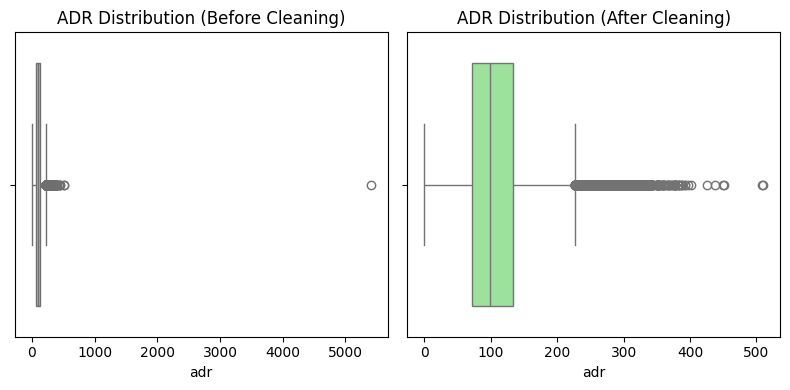


Top 5 highest adverage daily rate
The maximum ADR exceeds 5000 (left chart), which is unrealistic for hotel pricing and likely represents a data entry error.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize= (8,4))

threshold = 5000 # adr outlier threshold value
df_cleaned= df[df['adr'] <= threshold]

# First subplot with outliers
sns.boxplot(x=df['adr'], orient='h', color='skyblue', ax=axes[0])
axes[0].set_title('ADR Distribution (Before Cleaning)')

# Second subplot without outliers
sns.boxplot(x=df_cleaned['adr'], orient='h', color='lightgreen', ax=axes[1])
axes[1].set_title('ADR Distribution (After Cleaning)')

# show the plots
plt.tight_layout()
plt.show()

print()
print('Top 5 highest adverage daily rate')
df['adr'].sort_values(ascending=False).head()

print('The maximum ADR exceeds 5000 (left chart), which is unrealistic for hotel pricing and likely represents a data entry error.')

In the right chart, while the median ADR (~$100) is now more centrally positioned, indicating a typical hotel price around that value, there are still a few outliers present. These remaining outliers, although significantly reduced from the initial dataset, suggest that certain hotels may still have unusually high rates that could impact overall pricing trends. It’s important to consider these outliers when interpreting the data, as they may represent exceptional cases in the market.

In [ ]:
df = df[df['adr'] < 5000]

The ADR distribution shows several extreme outliers, including a value above 5000, which is far beyond typical hotel room prices.

In [ ]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,total_guests
count,87212.000000,87212.000000,87212.000000,87212.000000,87212.000000,87212.000000,87212.000000,87212.000000,87212.000000,87212.000000,87212.000000,87212.000000,87212.000000,87212.000000,87212.000000,87212.000000,87212.000000,87212.000000,87212.000000,87212,87212.000000
mean,0.275123,79.933140,2016.210556,26.833704,15.816585,1.004460,2.623653,1.875304,0.138811,0.010629,0.038561,0.030409,0.184069,0.268461,81.095939,0.746445,106.474586,0.084323,0.699055,2016-08-31 05:16:21.608035584,2.024744
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014-10-17 00:00:00,1.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,72.250000,0.000000,0.000000,2016-03-18 00:00:00,2.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,98.250000,0.000000,0.000000,2016-09-08 00:00:00,2.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,0.000000,134.100000,0.000000,1.000000,2017-03-05 00:00:00,2.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,6.000000,3.000000,2.000000,1.000000,26.000000,72.000000,18.000000,535.000000,391.000000,510.000000,8.000000,5.000000,2017-09-14 00:00:00,6.000000
std,0.446579,86.007665,0.685945,13.669261,8.835637,1.027342,2.039691,0.504886,0.455084,0.104213,0.192548,0.369382,1.733200,0.710633,109.983076,10.002027,51.870160,0.281685,0.832082,NaN,0.700681


### Interpretation

**Cancellation Rates**

The `is_canceled` column has a mean of approximately **0.27 (27%)**, suggesting that roughly **one quarter of bookings were canceled**.

**Arrival Dates**

The columns `arrival_date_year`, `arrival_date_month`, and `arrival_date_day_of_month` indicate that the dataset contains bookings from **2015 to 2017**.

**Stay Duration**

The variable `stays_in_weekend_nights` has an average of **about 1 night**, while `stays_in_week_nights` averages **about 2.62 nights**, suggesting that most bookings include **more weekday nights than weekend nights**.

**Adults and Children**

The `adults` column has a mean of **1.88**, indicating that the typical booking includes **1–2 adults**.  
The variables `children` (mean of 0.13) and `babies` (mean of 0.01) show that **most bookings do not include children or infants**.

**Pricing**

The `adr` (average daily rate) variable has a mean value of approximately **106.46** (with the maximum value reaches **5400** removed), suggesting the presence of **high-price hotels that may influence pricing analysis**.

**Customer History**

The `previous_bookings_not_canceled` variable has a mean of **0.18**, indicating that **most guests do not have a long booking history with the hotel**, suggesting repeat guests represent a relatively small share of reservations.

-------------------------------

## EDA Charts

### Cancellation by market segment

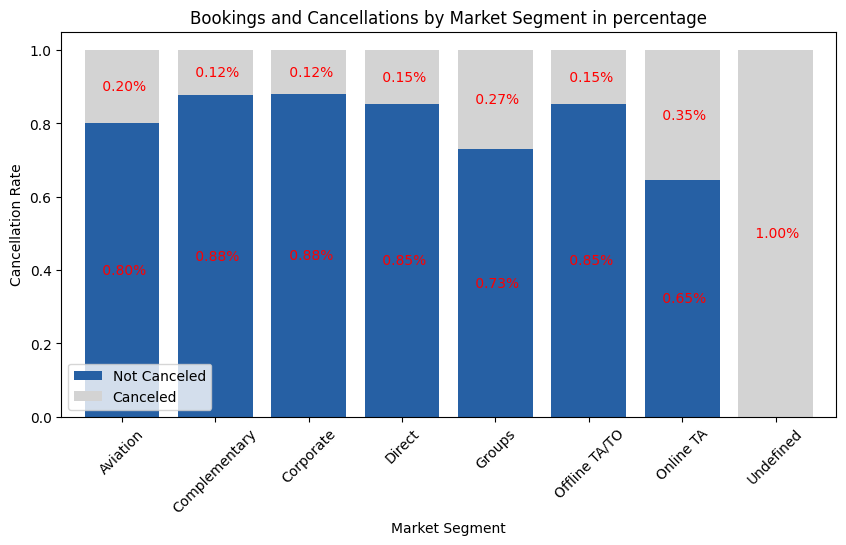

In [ ]:
segment_cancel = pd.crosstab(df['market_segment'], df['is_canceled'], normalize='index')

ax= segment_cancel.plot(
    kind='bar',
    stacked=True,
    figsize=(10,5),
    color=['#2660a4', 'lightgray'],
    width=0.8,
)

for container in ax.containers:
  labels = [f'{v: .2f}%' if v > 0  else '' for v in container.datavalues]
  ax.bar_label(container, labels=labels, label_type='center', color='red'
  )

plt.title('Bookings and Cancellations by Market Segment in percentage')
plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate')
plt.legend(['Not Canceled','Canceled'], loc='lower left')
plt.xticks(rotation=45)
plt.show()

Cancellation rates are highest for Groups and Online TA bookings and lowest for Corporate and Complementary bookings.

Cancellation vs Completion and by hotel type

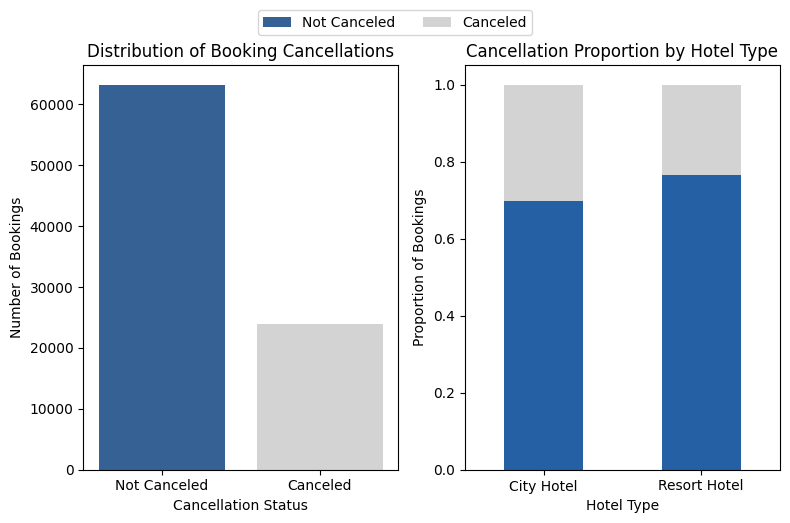

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(8,5))

# Chart 1
sns.countplot(
    x='is_canceled',
    hue='is_canceled',
    data=df,
    palette=['#2660a4','lightgray'],
    legend=False,
    ax=ax[0]
)

ax[0].set_title('Distribution of Booking Cancellations')
ax[0].set_xlabel('Cancellation Status')
ax[0].set_ylabel('Number of Bookings')
ax[0].set_xticks([0,1])
ax[0].set_xticklabels(['Not Canceled','Canceled'])


# Chart 2
pd.crosstab(df['hotel'], df['is_canceled'], normalize='index').plot(
    kind='bar',
    stacked=True,
    color=['#2660a4','lightgray'],
    ax=ax[1],
    legend=False
)

ax[1].set_title('Cancellation Proportion by Hotel Type')
ax[1].set_ylabel('Proportion of Bookings')
ax[1].set_xlabel('Hotel Type')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)

# Shared legend
fig.legend(
    ['Not Canceled','Canceled'],
    loc='upper center',
    # loc='lower right',
    bbox_to_anchor=(0.5, 1.05),
    ncol=2

)

plt.tight_layout()
plt.show()

Most bookings are completed, but cancellation rates differ by hotel type, with city hotels experiencing more cancellations than resort hotels.

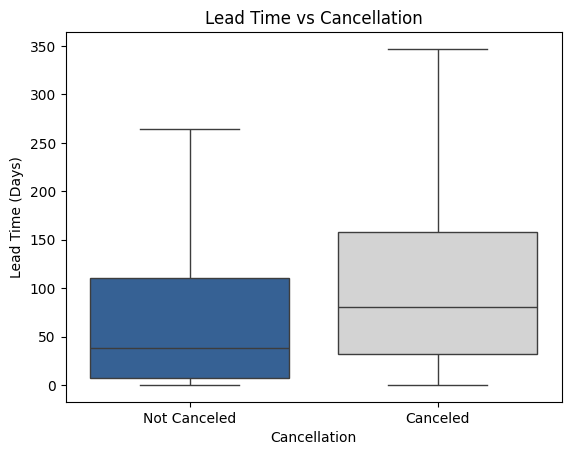

In [ ]:
sns.boxplot(
            x='is_canceled',
            y='lead_time',
            data=df,
            hue='is_canceled',
            palette={0: '#2660a4', 1: 'lightgray'},
            showfliers=False, # Outliers (leadtime > 700 days) are removed
            legend=False
)
plt.xticks([0,1],['Not Canceled','Canceled'])
plt.title('Lead Time vs Cancellation')
plt.xlabel('Cancellation')
plt.ylabel('Lead Time (Days)')
plt.show()



The adverage cancellation lead time is around 80 days. Cancelled bookings generally have longer lead times than non-cancelled bookings, suggesting that reservations made further in advance are more uncertain.

## Cancellation by deposit type

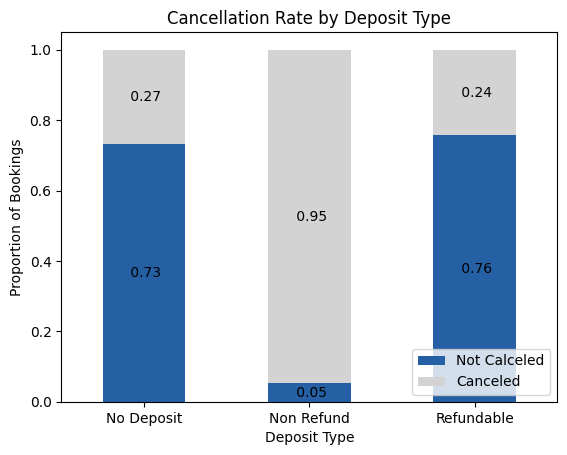

In [ ]:
deposit_cancel = pd.crosstab(df['deposit_type'], df['is_canceled'], normalize='index')
ax= deposit_cancel.plot(
    kind='bar',
    stacked=True,
    color=['#2660a4', 'lightgray']
)

for container in ax.containers:
  labels = [f'{v: .2f}' if v > 0  else '' for v in container.datavalues]
  ax.bar_label(container, labels=labels, label_type='center'
  )

plt.title('Cancellation Rate by Deposit Type')
plt.ylabel('Proportion of Bookings')
plt.xlabel('Deposit Type')
plt.xticks(rotation=0)
plt.legend(['Not Calceled', 'Canceled'], loc='lower right')
plt.show()



In [ ]:
# Deposit type count
df['deposit_type'].value_counts()

,count
deposit_type,
No Deposit,86068
Non Refund,1037
Refundable,107


In [ ]:
pd.crosstab(df['deposit_type'], df['is_canceled'])

is_canceled,0,1
deposit_type,,
No Deposit,63082,22986
Non Refund,55,982
Refundable,81,26


Most bookings are made without deposits. Non-refundable deposits show the highest cancellation rate, while refundable deposits have the lowest. However, refundable bookings account for only a small number of reservations, so **the percentage should be interpreted with caution.**

Cancellation by previous cancellations

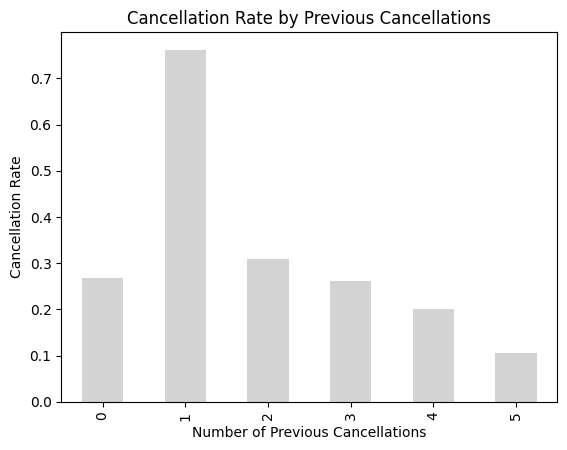

In [ ]:
cancel_rate = df.groupby('previous_cancellations')['is_canceled'].mean()

cancel_rate[cancel_rate.index <= 5].plot(kind='bar', color='lightgray')

plt.title('Cancellation Rate by Previous Cancellations')
plt.xlabel('Number of Previous Cancellations')
plt.ylabel('Cancellation Rate')
plt.show()

Guests with a history of previous cancellations tend to have higher cancellation rates for future bookings. However, very high values of previous cancellations appear infrequently in the dataset, so extreme cancellation rates for those groups should be interpreted cautiously.

-----------------

## Feature Engineering

Total stay length

In [ ]:
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

Total guests

In [ ]:
df['total_guests'] = df['adults'] + df['children'] + df['babies']

Lead time categories

In [ ]:
df['lead_time_group'] = pd.cut(
    df['lead_time'],
    bins=[-1,7,30,90,365,800],
    labels=['last_min', 'short', 'medium', 'long', 'very_long'],
    include_lowest=True,
    right=False
)

Family indicator

In [ ]:
df['has_children'] = ((df['children']+ df['babies']) >0).astype(int)

Added variables are created to capture useful booking features such as total stay duration, total number of guests, and booking lead time categories. These engineered features help provide clearer insights during analysis and modeling.

In [ ]:
df.shape

(87212, 35)

In [ ]:
# Make a copy of the cleaned dataset and save it for reference
df_clean = df.copy()

----------------------

Heatmap Chart

In [ ]:
features_heatmap = [
    'is_canceled',
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'total_guests',
    'total_nights'
]

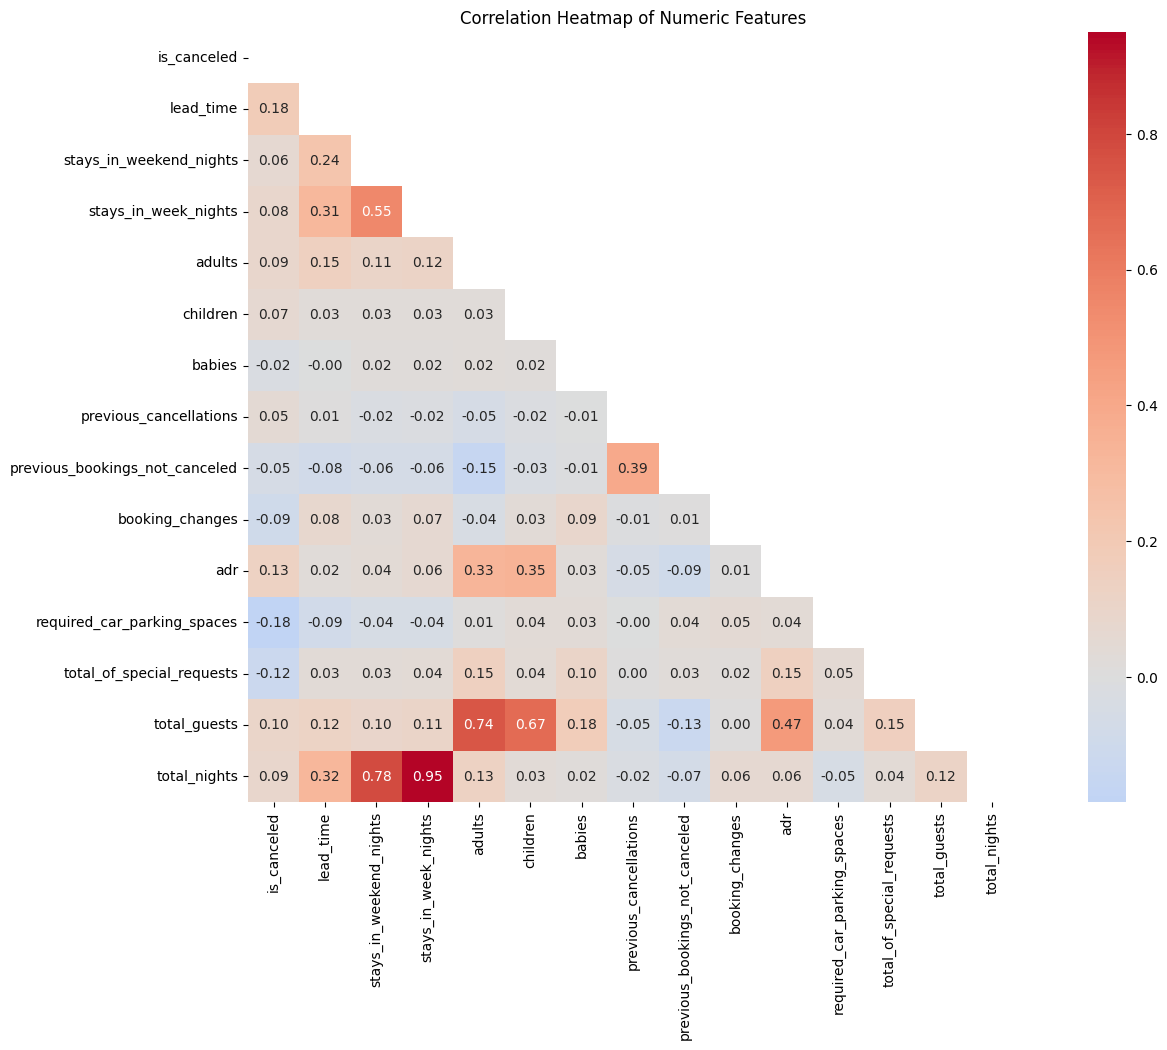

In [ ]:
corr = df[features_heatmap].corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(18,10))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    # cmap='RdBu_r',
    cmap='coolwarm',
    fmt=".2f",
    center=0,
    square=True
)

plt.title('Correlation Heatmap of Numeric Features')
plt.show()

The heatmap shows several redundant variables. For example, `total_nights` is highly correlated with `stays_in_week_nights` (0.95) and `stays_in_weekend_nights` (0.78), while `total_guests` is strongly correlated with `adults` (0.74) and `children` (0.67). These relationships suggest overlapping information among features.

Person Correlation Table

In [ ]:
corr_table = df[features_heatmap].corr()[['is_canceled']]\
              .sort_values(by='is_canceled', ascending=False)\
              .drop('is_canceled')
corr_table

,is_canceled
lead_time,0.183973
adr,0.133256
total_guests,0.102212
adults,0.085791
total_nights,0.085257
stays_in_week_nights,0.083990
children,0.067048
stays_in_weekend_nights,0.060857
previous_cancellations,0.051534
babies,-0.021198


Most numerical features show weak correlations with booking cancellations. Lead time and average daily rate (ADR) show modest positive relationships with cancellations, while required parking spaces and special requests show negative relationships, suggesting stronger commitment among these bookings.

----------------------
## Models

Logistic Regression

A Logistic Regression model is used as the initial baseline classifier to predict booking cancellations. Since `is_canceled` is a binary outcome, Logistic Regression provides an interpretable and efficient starting point for evaluating how booking characteristics relate to cancellation behavior.

## Model Evaluation

Models are evaluated using classification metrics:
* Accuracy
* Precision
* Recall
* F1 Score

Because cancellations are less frequent than non-cancellations, precision and recall for the canceled class are especially important.

In [ ]:
# target
y = df['is_canceled']

# features
features = [
'hotel',
'lead_time',
'arrival_date_year',
'arrival_date_month',
'arrival_date_week_number',
'total_nights',
'total_guests',
'babies',
'meal',
'country',
'market_segment',
'distribution_channel',
'is_repeated_guest',
'previous_cancellations',
'previous_bookings_not_canceled',
'reserved_room_type',
'booking_changes',
'deposit_type',
'agent',
'days_in_waiting_list',
'customer_type',
'adr',
'required_car_parking_spaces',
'total_of_special_requests'
]

In [ ]:
X = df[features].copy() # Make a copy for future reference

# categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# LR model pipeline
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# train
lr_model.fit(X_train, y_train)

# predict
y_pred_lr = lr_model.predict(X_test)

y_pred_prob_lr = lr_model.predict_proba(X_test)[:,1]

Random Forest is a tree-based ensemble model to capture nonlinear relationships and interactions among booking features. Unlike Logistic Regression, which assumes a linear relationship between predictors and the outcome, Random Forest constructs multiple decision trees using bootstrapped samples of the data and aggregates their predictions. This approach can improve predictive performance and robustness, particularly when complex patterns exist in the dataset. The Random Forest model is evaluated alongside Logistic Regression to determine whether a more flexible, non-linear method improves cancellation prediction accuracy.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_pred_prob_rf = rf_model.predict_proba(X_test)[:,1]

## Model Comparison

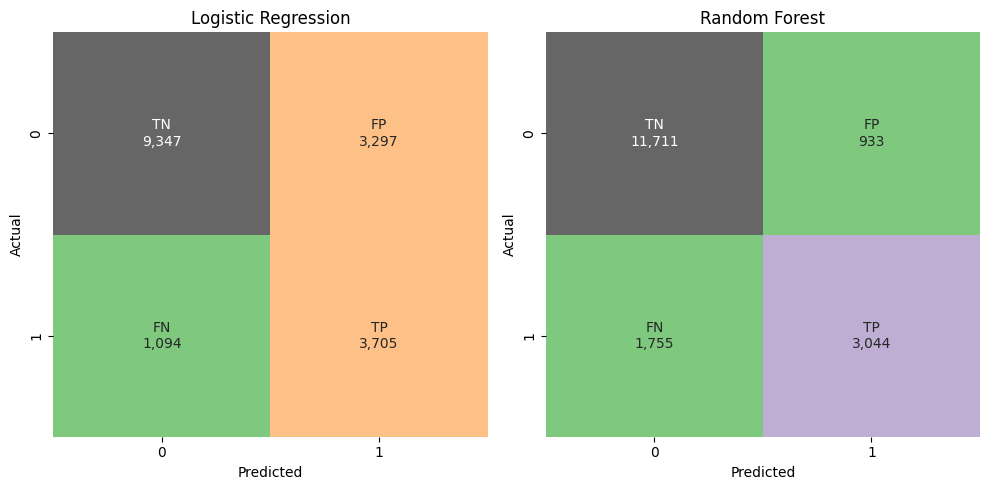


Logistic Regression Accuracy: 0.75
Random Forest Accuracy: 0.85


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

# LR confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
labels_lr = np.array([
    [f'TN\n{cm_lr[0,0]:,}', f'FP\n{cm_lr[0,1]:,}'],
    [f'FN\n{cm_lr[1,0]:,}', f'TP\n{cm_lr[1,1]:,}']
])

sns.heatmap(cm_lr, annot=labels_lr, fmt='', cmap='Accent', cbar=False, ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# RF confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
labels_rf = np.array([
    [f'TN\n{cm_rf[0,0]:,}', f'FP\n{cm_rf[0,1]:,}'],
    [f'FN\n{cm_rf[1,0]:,}', f'TP\n{cm_rf[1,1]:,}']
])


sns.heatmap(cm_rf, annot=labels_rf, fmt='', cmap='Accent', cbar=False, ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print()
print('Logistic Regression Accuracy:', round(accuracy_score(y_test, y_pred_lr),2))
print('Random Forest Accuracy:', round(accuracy_score(y_test, y_pred_rf),2))

In [ ]:
# LR Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_lr_df = pd.DataFrame(
    cm_lr,
    index=['Actual Not Canceled', 'Actual Canceled'],
    columns=['Predicted Not Canceled', 'Predicted Canceled']
)
print('================= LR Confusion Matrix ================')
display(cm_lr_df)

print('\n\n')


# RF Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_rf_df = pd.DataFrame(
    cm_rf,
    index=['Actual Not Canceled', 'Actual Canceled'],
    columns=['Predicted Not Canceled', 'Predicted Canceled']
)
print('================ RF Confusion Matrix ================')
display(cm_rf_df)

print('\n\n')

print('Classification Report for Logistic Regression')
print(classification_report(y_test, y_pred_lr))
print()
print('Classification Report for Random Forest')
print(classification_report(y_test, y_pred_rf))

================= LR Confusion Matrix ================


,Predicted Not Canceled,Predicted Canceled
Actual Not Canceled,9347,3297
Actual Canceled,1094,3705





================ RF Confusion Matrix ================


,Predicted Not Canceled,Predicted Canceled
Actual Not Canceled,11711,933
Actual Canceled,1755,3044





Classification Report for Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.74      0.81     12644
           1       0.53      0.77      0.63      4799

    accuracy                           0.75     17443
   macro avg       0.71      0.76      0.72     17443
weighted avg       0.79      0.75      0.76     17443


Classification Report for Random Forest
              precision    recall  f1-score   support

           0       0.87      0.93      0.90     12644
           1       0.77      0.63      0.69      4799

    accuracy                           0.85     17443
   macro avg       0.82      0.78      0.80     17443
weighted avg       0.84      0.85      0.84     17443



The Logistic Regression classification report shows that When the  model predicts that a booking will not be canceled, it is correct 90% of the time. It also correctly identifies 77% of cancellations, but its precision is lower (53%), meaning some bookings predicted as canceled are actually completed. This Logistic Regression is the first baseline model.

The Random Forest classification report shows that When the  model predicts that a booking will not be canceled, it is slightly less correct 87% of the time. It also correctly identifying fewer cancellations at 63%, but its precision is higher (77%), meaning some bookings predicted as canceled are actually completed.

Random Forest achieves the highest overall accuracy (85% vs 75%)and precision when predicting cancellations. However, Logistic Regression has higher recall for canceled bookings, meaning it identifies a larger share of actual cancellations. This highlights the trade-off between minimizing false positives and capturing more true cancellations.

The F1-scores for both completed bookings and canceled bookings are higher for Random Forest (0.90 and 0.69) than for Logistic Regression (0.81 and 0.63). This indicates that Random Forest provides a better overall balance between precision and recall across both classes, resulting in stronger overall predictive performance.


-----------------

ROC Curves and AUC Scores

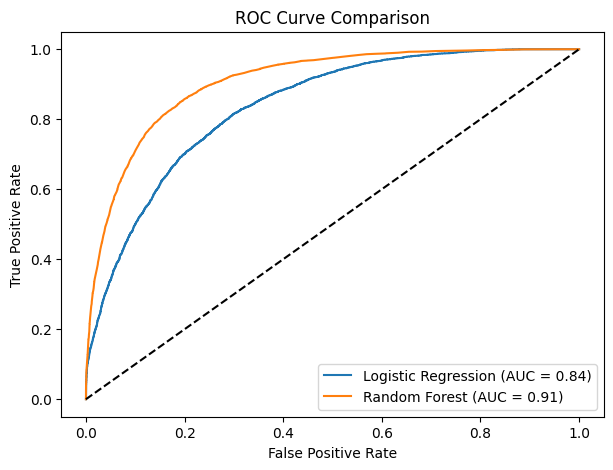

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities

# y_pred_lr = lr_model.predict(X_test)

y_pred_prob_lr = lr_model.predict_proba(X_test)[:,1]
y_pred_prob_rf = rf_model.predict_proba(X_test)[:,1]

# y_prob_lr = lr_model.predict_proba(X_test)[:,1]
# y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# Compute ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_prob_rf)

# Compute AUC
auc_lr = roc_auc_score(y_test, y_pred_prob_lr)
auc_rf = roc_auc_score(y_test, y_pred_prob_rf)

# Plot
plt.figure(figsize=(7,5))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')

plt.plot([0,1],[0,1],'k--')  # random classifier line

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

The ROC curve compares the classification performance of Logistic Regression and Random Forest across different probability thresholds. The Random Forest model achieves a higher AUC (0.91) than Logistic Regression (0.84), indicating a stronger ability to distinguish between canceled and non-canceled bookings.

The steeper and wider curve of the Random Forest model shows that it achieves a higher true positive rate for the same false positive rate across most thresholds. This suggests that Random Forest provides better overall predictive performance for the cancellation prediction task.

-----------


## Key Insights & Business Implications

1. Cancellation prediction can support revenue management.
Predicting cancellations allows hotels to anticipate lost bookings and adjust pricing, overbooking strategies, or promotional offers to maintain occupancy levels.

2. Model choice affects operational strategy.
Logistic Regression identifies a larger share of actual cancellations, which may help hotels proactively manage potential revenue loss. Random Forest, however, provides more reliable predictions when identifying cancellations, reducing false alarms.

3. Trade-off between recall and precision.
If the business goal is to capture as many potential cancellations as possible, Logistic Regression may be preferred. If the goal is to avoid unnecessary interventions, Random Forest may be the better choice.

4. Predictive analytics can improve operational planning.
Early detection of cancellation risk allows hotels to adjust staffing, marketing campaigns, and room inventory management.


---------------

## Conclusion
This analysis compared Logistic Regression and Random Forest models to predict hotel booking cancellations. While Logistic Regression serves as a strong baseline and captures a larger share of actual cancellations, Random Forest provides better overall predictive performance, achieving higher accuracy and stronger F1-scores across both classes. These results demonstrate the value of ensemble models when modeling complex booking behavior.

Future work could extend this analysis by exploring additional predictive tasks such as forecasting booking revenue, predicting average daily rate (ADR), or improving cancellation prediction using additional features and more advanced models.